In [1]:
!pip install scikit-image

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
from aicspylibczi import CziFile
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter 
from skimage.filters import threshold_otsu

In [3]:
pth = Path('img/SEcell7.czi')
czi = CziFile(pth)

In [4]:
img_frames = []
for t in range(0,250):
    frame_t, _ = czi.read_image(Z=0, T=t, C=0, H=0)
    img_frames.append(frame_t[0, 0, 0, 0, :, :])

img_frames = np.array(img_frames)
img_frames.shape

(250, 512, 512)

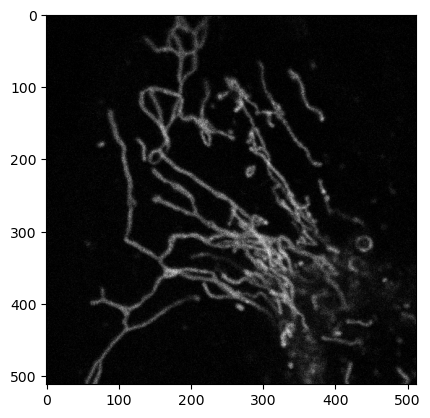

In [ ]:
plt.imshow(img_frames[0], cmap="gray")

In [15]:
frame_idx = 131
frame = np.copy(img_frames[frame_idx])

frame = gaussian_filter(frame, sigma=1.5)

threshold = threshold_otsu(frame)

# Apply the threshold mask
otsu_frame = frame > threshold

In [34]:
def plot_patches(original_patches, patch_size, stride, otsu_patches=None):
    x_positions = range(0, frame.shape[0] - patch_size + 1, stride)
    y_positions = range(0, frame.shape[1] - patch_size + 1, stride)

    nrows = len(x_positions)
    ncols = len(y_positions)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(16, 19),
        squeeze=False
    )

    if otsu_patches:
        for idx, (tile, mask) in enumerate(zip(original_patches, otsu_patches)):
            row = idx // ncols
            col = idx % ncols

            axes[row, col].imshow(tile, cmap="gray")
            axes[row, col].contour(
                mask,
                levels=[0.5],
                colors="red",
                linewidths=1
            )
            axes[row, col].axis("off")
            
    else:
        for idx, tile in enumerate(original_patches):
            row = idx // ncols
            col = idx % ncols

            axes[row, col].imshow(tile, cmap="gray")
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

In [37]:
def create_patches(tile_size : int, stride_proportion : float, otsu : bool=False):
    stride = int(tile_size * stride_proportion)

    patches = [
        frame[x:x + tile_size, y:y + tile_size]
        for x in range(0, frame.shape[0] - tile_size + 1, stride)
        for y in range(0, frame.shape[1] - tile_size + 1, stride)
    ]
    
    if otsu:
        otsu_patches = [threshold_otsu(tile) for tile in patches]

        otsu_result_patches = [
            tile > otsu_threshold
            for tile, otsu_threshold in zip(patches, otsu_patches)
        ]

    else:
        otsu_result_patches = None

    plot_patches(original_patches=patches, otsu_patches=otsu_result_patches, patch_size=tile_size, stride=stride)

/tmp/ipykernel_16427/1320768864.py:21: UserWarning: No contour levels were found within the data range.
  axes[row, col].contour(


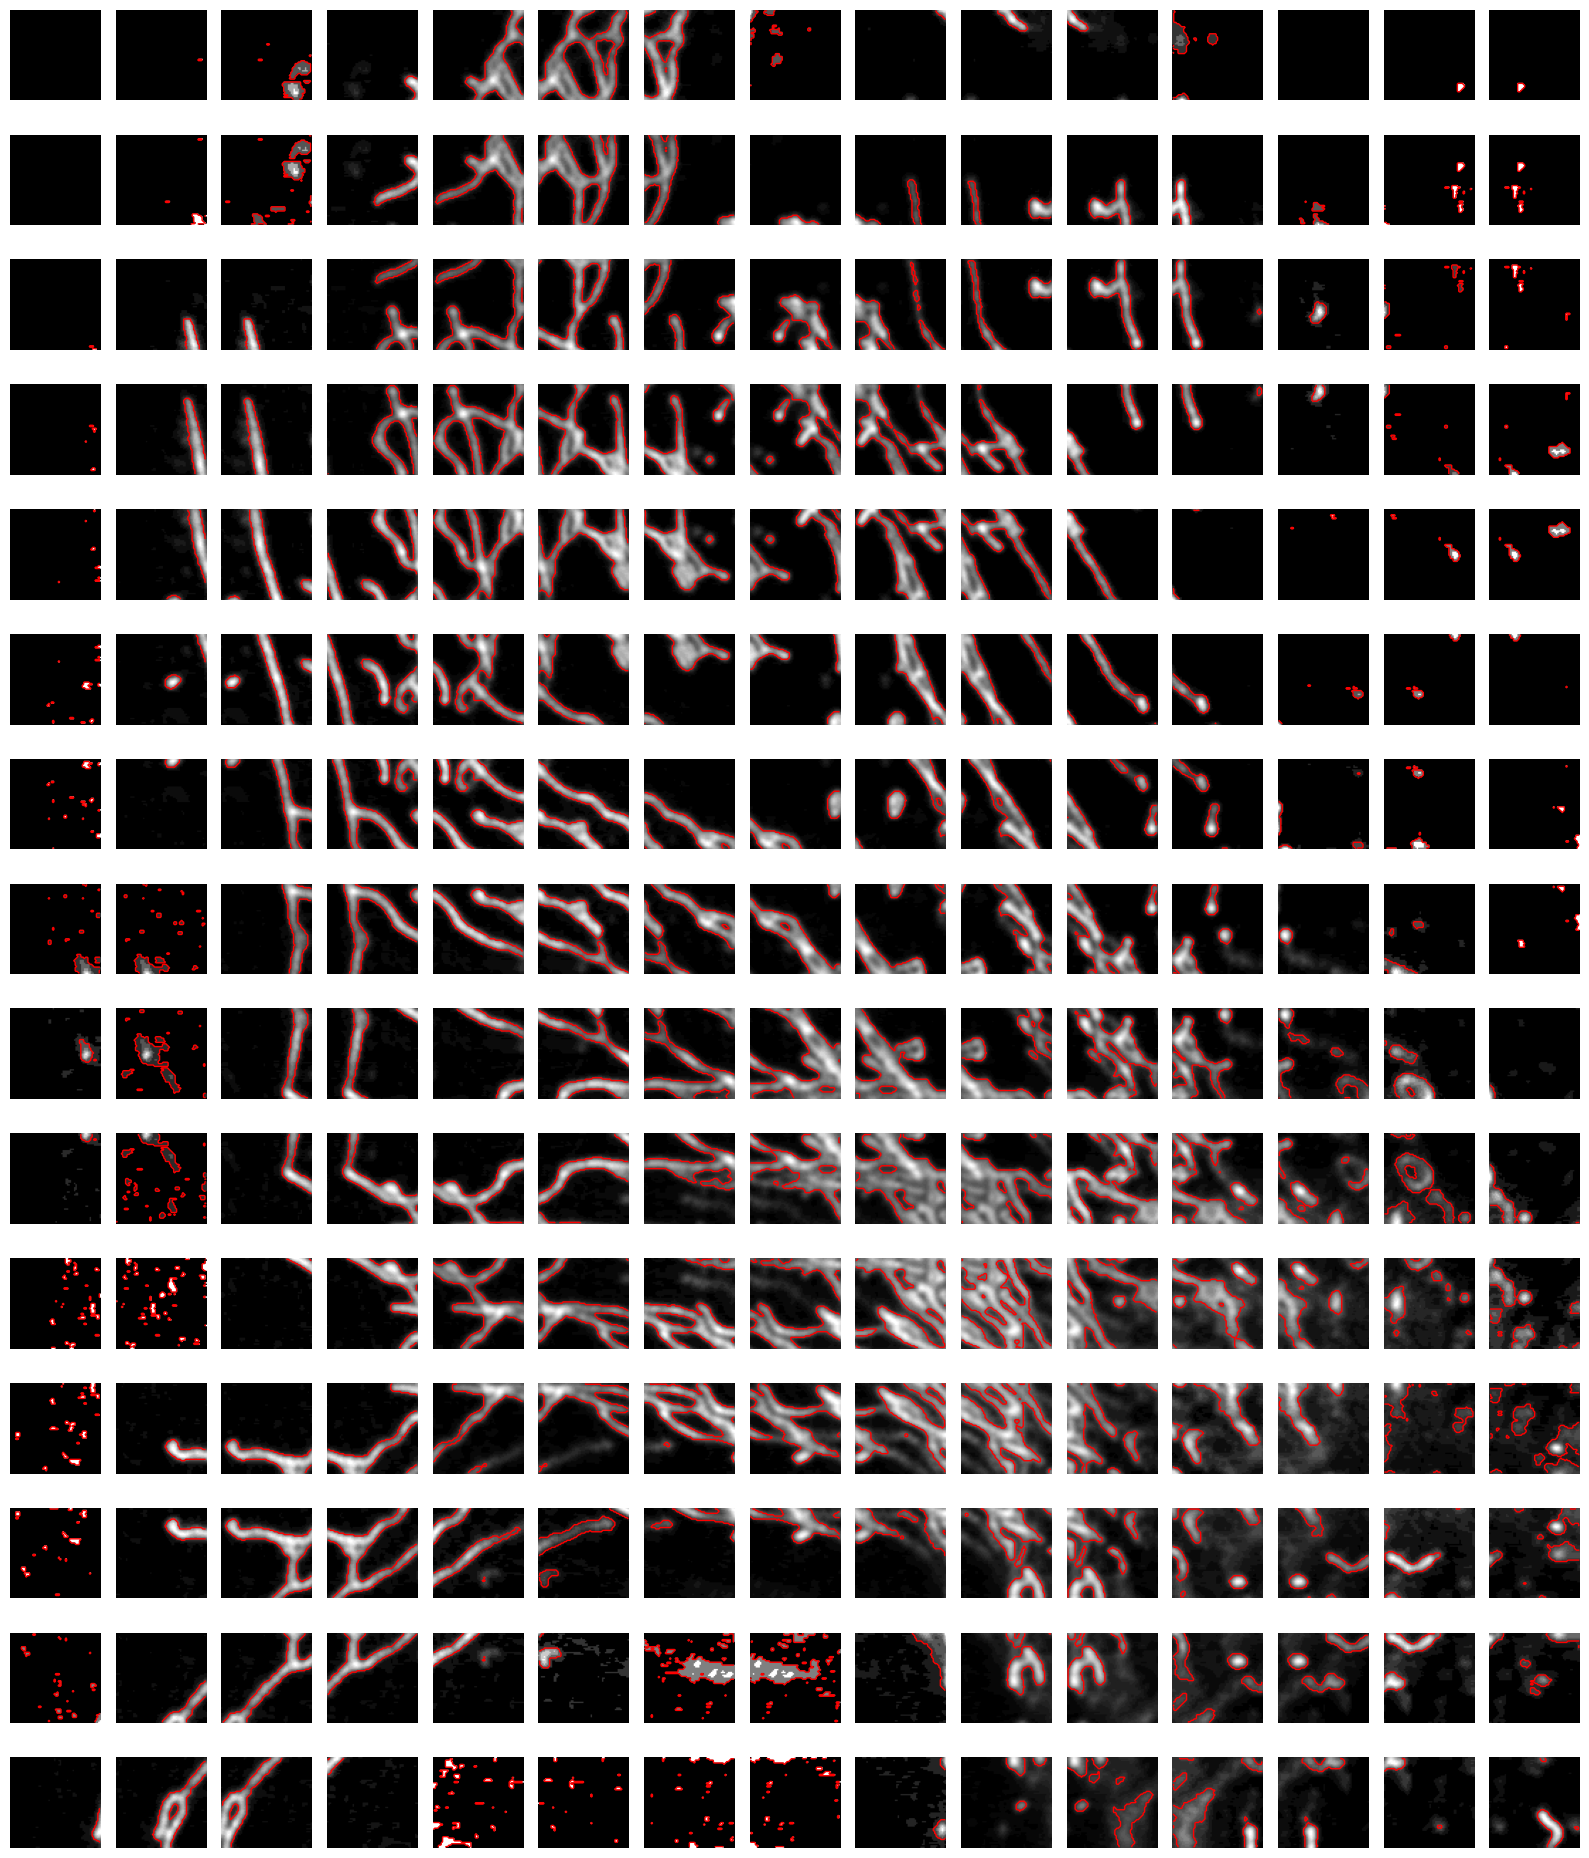

In [38]:
tile_size_1 = 64
stride_proportion_1 = 1/2

create_patches(tile_size=tile_size_1, stride_proportion=stride_proportion_1, otsu=True)

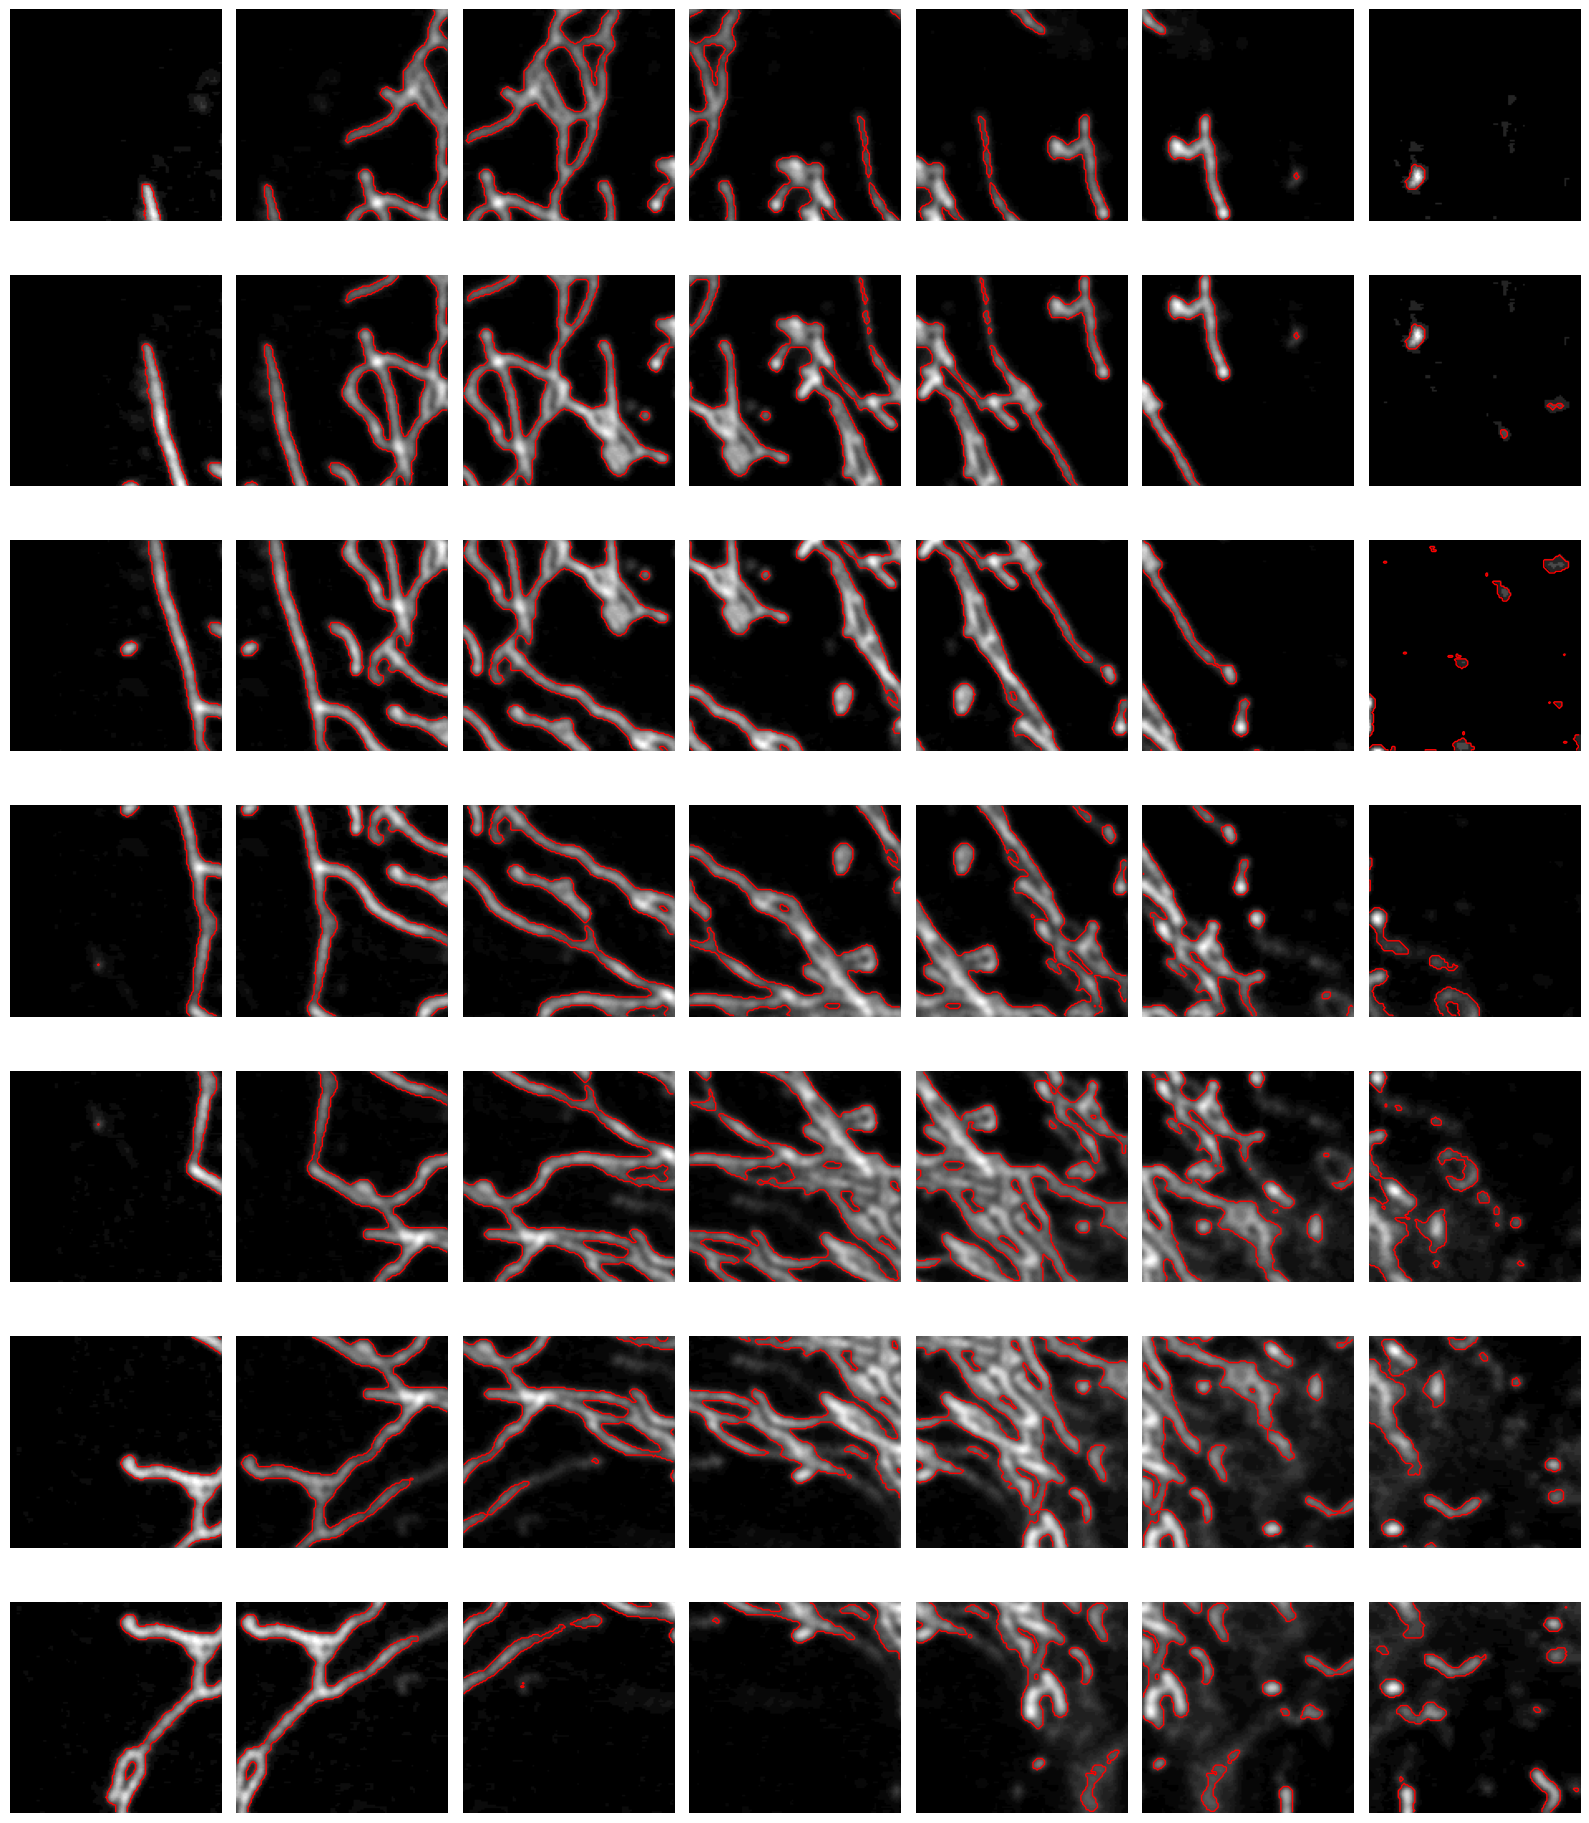

In [39]:
tile_size_2 = 128
stride_proportion_2 = 1/2

create_patches(tile_size=tile_size_2, stride_proportion=stride_proportion_2, otsu=True)

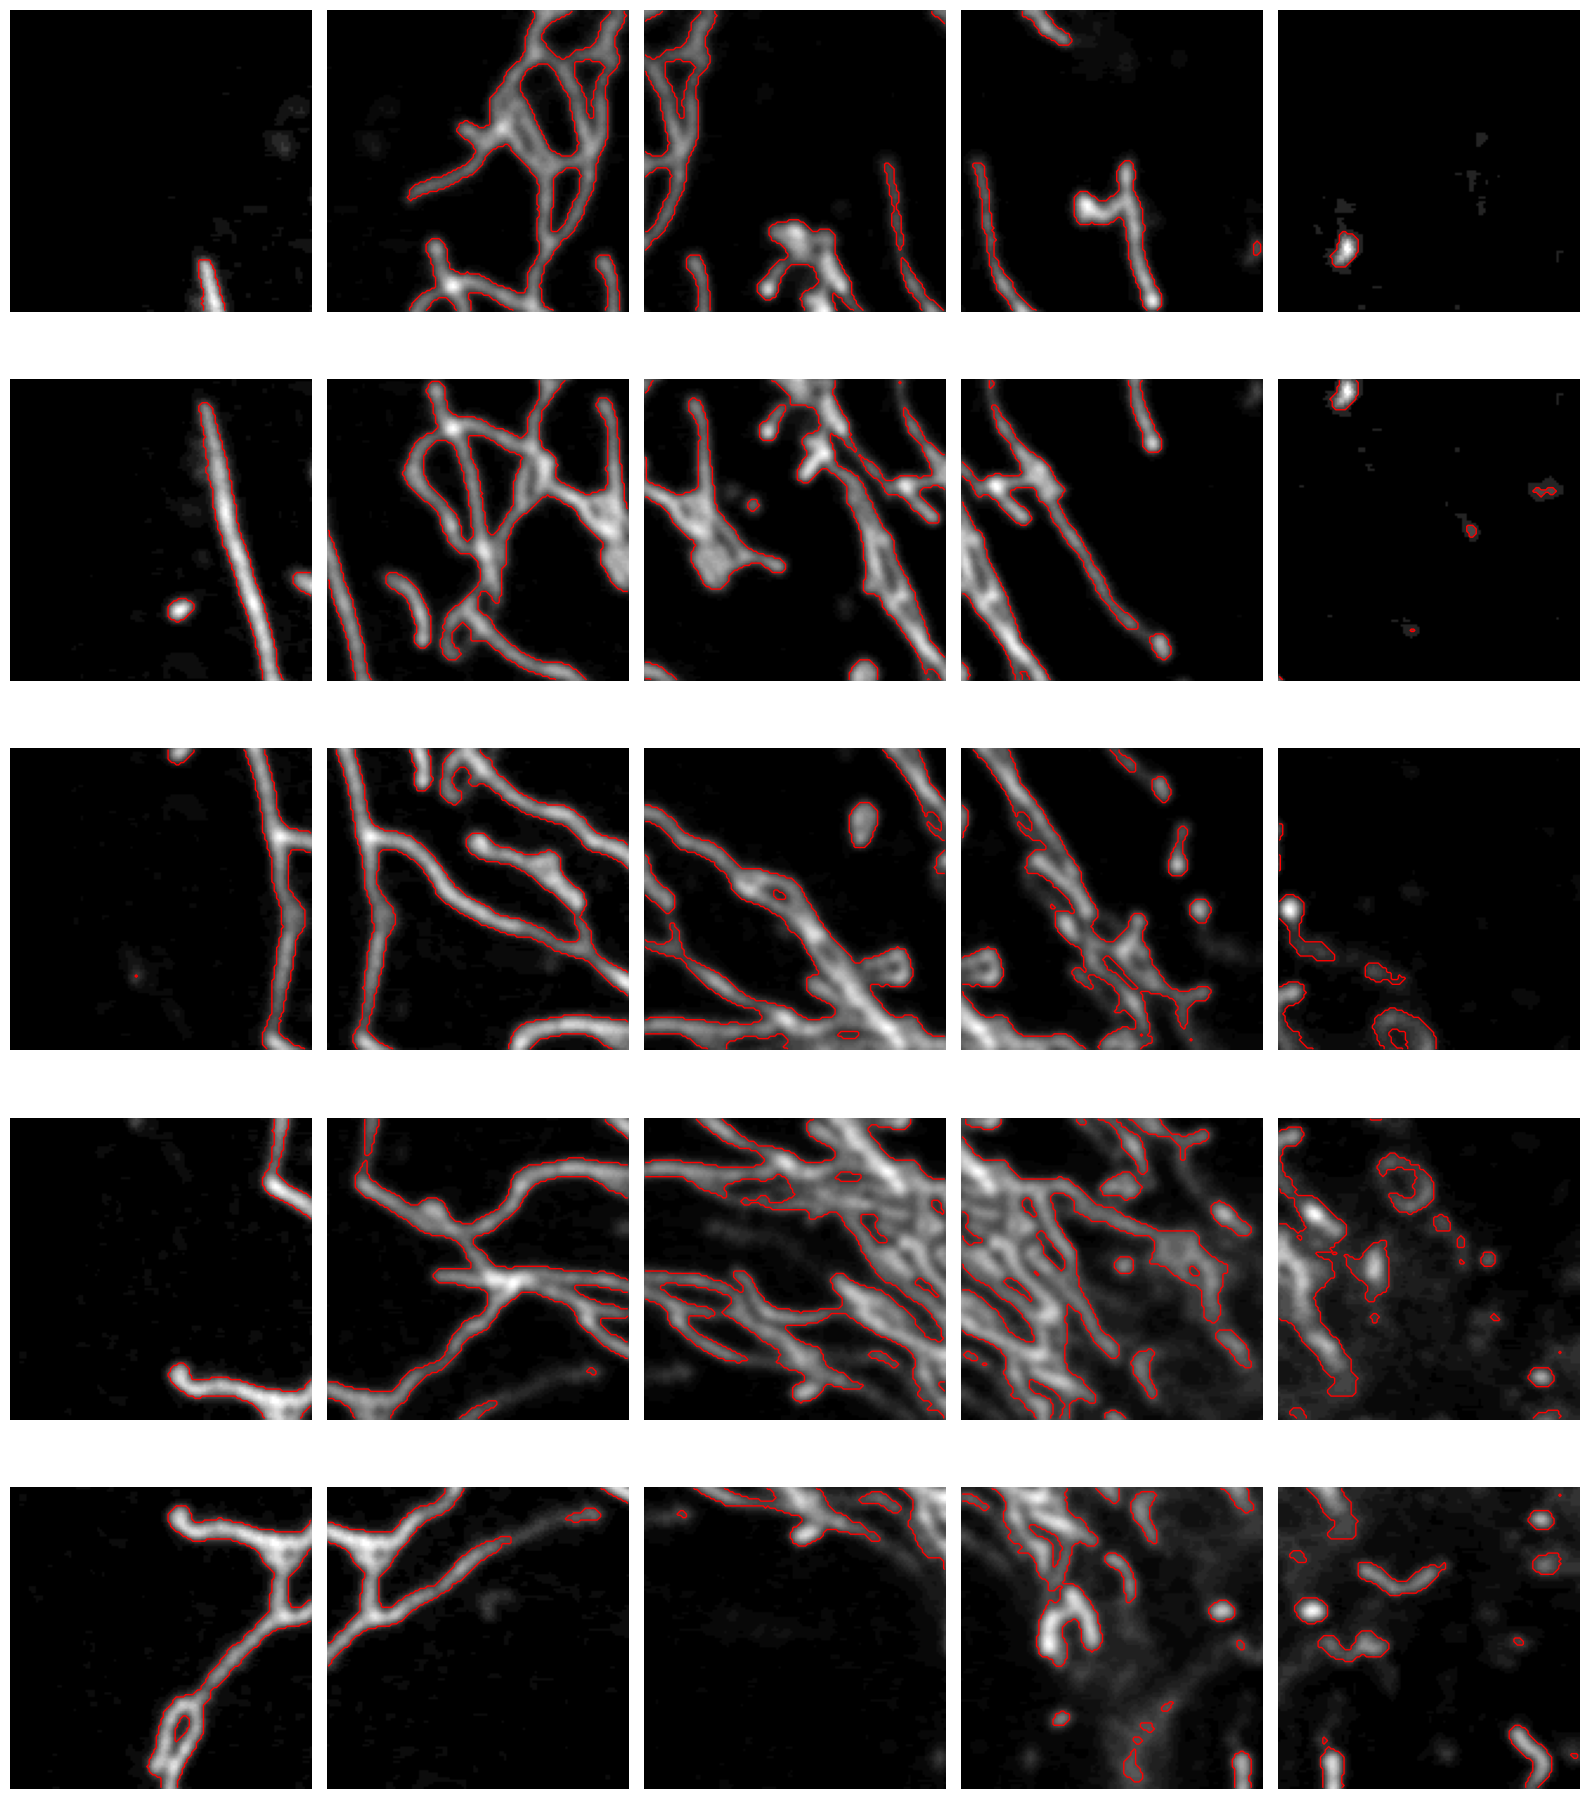

In [41]:
tile_size_3 = 128
stride_proportion_3 = 3/4

create_patches(tile_size=tile_size_3, stride_proportion=stride_proportion_3, otsu=True)

In [63]:
from skimage.filters import gaussian
from skimage.morphology import skeletonize
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects

In [65]:
imagen_original = img_frames[0]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


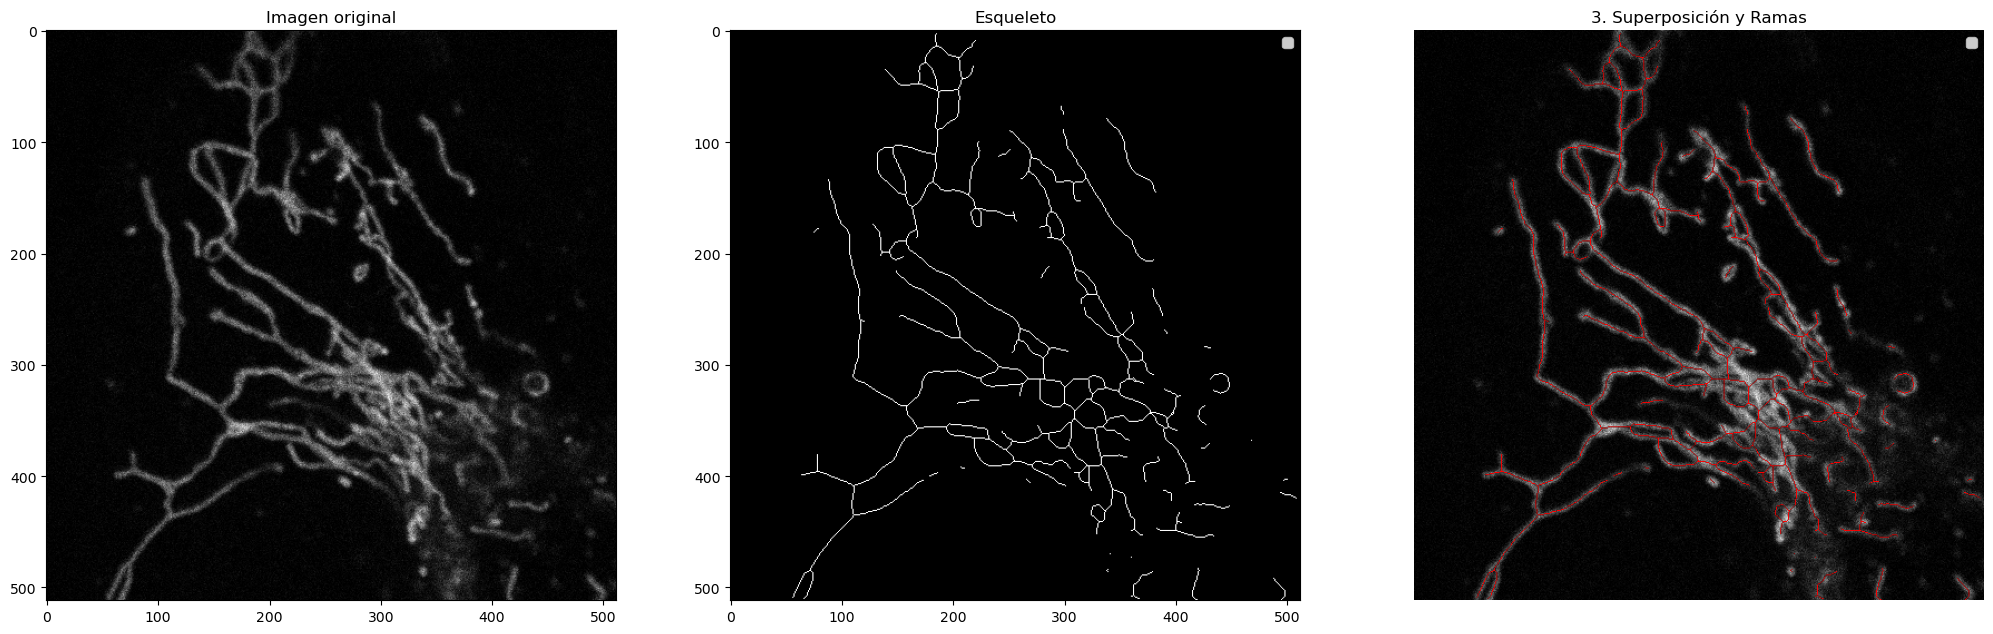

In [66]:
# 1. Suavizado (mantenemos igual para quitar grano)
img_blurred = gaussian(imagen_original, sigma=1.2)

# 2. Umbral Global (Otsu o Triangle funcionan excelente aquí)
# Probá con threshold_otsu primero, si quedan filamentos tenues afuera, probá threshold_triangle
thresh = threshold_otsu(img_blurred)
binary_raw = img_blurred > thresh

# 3. Limpieza: Eliminamos motas de ruido flotantes que midan menos de 20 píxeles
binary = remove_small_objects(binary_raw, min_size=20)

# 4. Esqueletización (ahora sobre la máscara limpia)
skeleton = skeletonize(binary)

# # 5. Visualización
fig, ax = plt.subplots(1, 3, figsize=(25, 15))
ax[0].imshow(img_frames[0], cmap='gray')
ax[0].set_title('Imagen original')

# Superponemos las bifurcaciones (ramas) sobre el esqueleto
ax[1].imshow(skeleton, cmap='gray')
ax[1].set_title('Esqueleto')
ax[1].legend()

# Creamos una máscara semi-transparente para el esqueleto (color rojo)
mask_skeleton = np.zeros((*skeleton.shape, 4)) # RGBA
mask_skeleton[skeleton] = [1, 0, 0, 1] # Rojo sólido donde hay esqueleto
ax[2].imshow(imagen_original, cmap='gray')
ax[2].imshow(mask_skeleton)
ax[2].set_title('Imagen original + esqueleto')
ax[2].legend(loc='upper right')
ax[2].axis('off')

plt.show()
